# – LAB 9

Simulación Monte Carlo del álbum de estampas.

Este notebook imprime todos los resultados directamente en las celdas y muestra la gráfica al final.

In [9]:
print('═' * 60)
print('P1. Cantidad mínima de sobres para completar CON intercambios')
print('═' * 60)
print(f'Mínimo observado = {min(r_con)}')
print(f'E[sobres]        = {E_con:.4f}')
print(f'Costo esperado   = Q{E_con * PRECIO_SOBRE:.2f}')
print('═' * 60)
print('P2. ¿Más eficiente: cajas o sobres individuales?')
print('═' * 60)
print('(Evaluado por costo total en Q)')
for c in range(MAX_CAJAS + 1):
    marca = '  ← ÓPTIMO' if c == cajas_opt else ''
    print(f'{c} caja(s): E[costo] = Q{costos_esp[c]:>9.4f}{marca}')
print('═' * 60)
print('P3. E[repetidas en una caja]')
print('═' * 60)
print(f'E[repetidas]  = {E_reps:.4f}')
print(f'Total abierto = {SOBRES_CAJA * ESTAMPAS_SOBRE} estampas por caja')
print(f'E[únicas]     = {SOBRES_CAJA * ESTAMPAS_SOBRE - E_reps:.4f}')
print('═' * 60)
print(f'P4. E[estampas únicas con Q{PRESUPUESTO:.0f}] — con vs sin intercambios')
print('═' * 60)
print(f'(Se compran {sobres_Q1000} sobres = {sobres_Q1000 * ESTAMPAS_SOBRE} estampas abiertas)')
print(f'Sin intercambios: {E_pres_sin:.4f} únicas  ({100 * E_pres_sin / N:.2f}% del álbum)')
print(f'Con intercambios: {E_pres_con:.4f} únicas  ({100 * E_pres_con / N:.2f}% del álbum)')
print(f'Ganancia:        +{E_pres_con - E_pres_sin:.4f} estampas con intercambios')
print(f'E[sobres para COMPLETAR sin intercambios] = {E_sin:.4f}  -> Q{E_sin * PRECIO_SOBRE:,.2f}')
print(f'E[sobres para COMPLETAR con intercambios] = {E_con:.4f}  -> Q{E_con * PRECIO_SOBRE:,.2f}')
print('═' * 60)
print('[P5] Umbral de estampas donde P(nueva) < 30%')
print('═' * 60)
print(f'P(nueva | k) = (N-k)/N < 0.30  ⟺  k > 0.70×{N} = {0.70 * N}')
print(f'k = {k30}  ->  P(nueva) = {p30:.4f}  (< 0.30)')
print(f'k = {k30 - 1}  ->  P(nueva) = {(N - k30 + 1) / N:.4f}  (≥ 0.30)')

════════════════════════════════════════════════════════════
P1. Cantidad mínima de sobres para completar CON intercambios
════════════════════════════════════════════════════════════
Mínimo observado = 196
E[sobres]        = 196.0000
Costo esperado   = Q980.00
════════════════════════════════════════════════════════════
P2. ¿Más eficiente: cajas o sobres individuales?
════════════════════════════════════════════════════════════
(Evaluado por costo total en Q)
0 caja(s): E[costo] = Q 980.0000  ← ÓPTIMO
1 caja(s): E[costo] = Q 985.8400
2 caja(s): E[costo] = Q1039.5175
3 caja(s): E[costo] = Q1131.7650
4 caja(s): E[costo] = Q1254.2550
5 caja(s): E[costo] = Q1399.6950
6 caja(s): E[costo] = Q1563.4100
7 caja(s): E[costo] = Q1740.8575
8 caja(s): E[costo] = Q1928.8450
9 caja(s): E[costo] = Q2124.8375
10 caja(s): E[costo] = Q2327.9775
════════════════════════════════════════════════════════════
P3. E[repetidas en una caja]
════════════════════════════════════════════════════════════
E[repetida

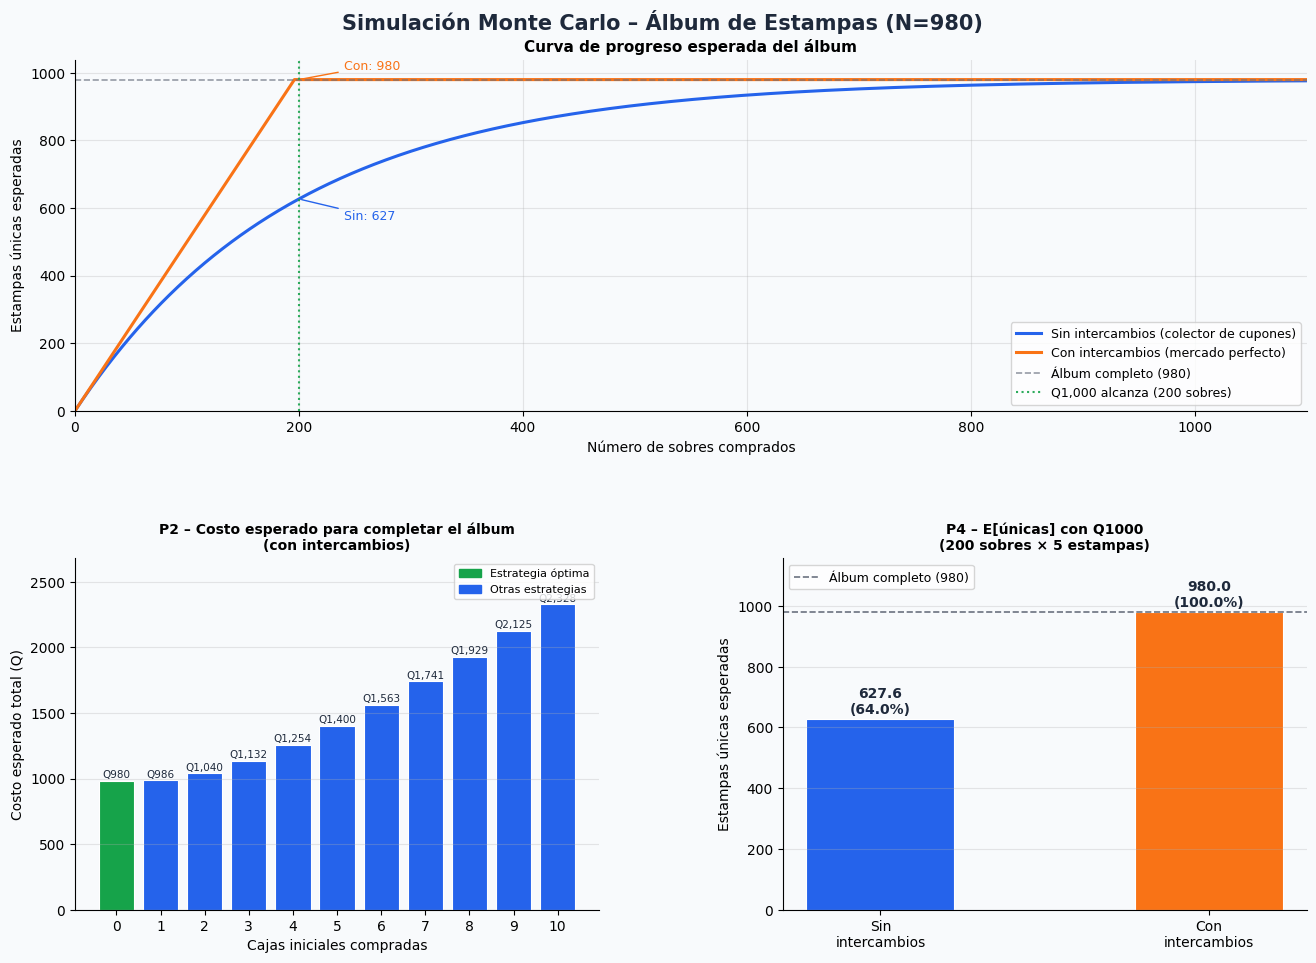

Gráfica mostrada en el notebook.


In [10]:
AZUL = '#2563EB'
NARANJA = '#F97316'
VERDE = '#16A34A'
GRIS = '#6B7280'
BG = '#F8FAFC'

fig = plt.figure(figsize=(14, 10), facecolor=BG)
fig.suptitle(
    'Simulación Monte Carlo – Álbum de Estampas (N=980)',
    fontsize=15, fontweight='bold', y=0.98, color='#1E293B'
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35, left=0.08, right=0.96, top=0.93, bottom=0.08)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ks = np.arange(0, 1200)
e_sin_analitica = N * (1 - ((N - 1) / N) ** (ESTAMPAS_SOBRE * ks))
e_con_lineal = np.minimum(ESTAMPAS_SOBRE * ks, N).astype(float)

ax1.plot(ks, e_sin_analitica, color=AZUL, lw=2.2, label='Sin intercambios (colector de cupones)')
ax1.plot(ks, e_con_lineal, color=NARANJA, lw=2.2, label='Con intercambios (mercado perfecto)')
ax1.axhline(N, color=GRIS, lw=1.2, ls='--', alpha=0.7, label=f'Álbum completo ({N})')
ax1.axvline(sobres_Q1000, color=VERDE, lw=1.5, ls=':', alpha=0.9, label=f'Q1,000 alcanza ({sobres_Q1000} sobres)')

y_sin_1000 = N * (1 - ((N - 1) / N) ** (ESTAMPAS_SOBRE * sobres_Q1000))
y_con_1000 = min(ESTAMPAS_SOBRE * sobres_Q1000, N)
ax1.annotate(f'Sin: {y_sin_1000:.0f}', xy=(sobres_Q1000, y_sin_1000), xytext=(sobres_Q1000 + 40, y_sin_1000 - 60), arrowprops=dict(arrowstyle='-', color=AZUL), color=AZUL, fontsize=9)
ax1.annotate(f'Con: {y_con_1000:.0f}', xy=(sobres_Q1000, y_con_1000), xytext=(sobres_Q1000 + 40, y_con_1000 + 30), arrowprops=dict(arrowstyle='-', color=NARANJA), color=NARANJA, fontsize=9)

ax1.set_xlim(0, 1100)
ax1.set_ylim(0, N * 1.06)
ax1.set_xlabel('Número de sobres comprados', fontsize=10)
ax1.set_ylabel('Estampas únicas esperadas', fontsize=10)
ax1.set_title('Curva de progreso esperada del álbum', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.set_facecolor(BG)
ax1.grid(True, alpha=0.3)

cajas_labels = [str(c) for c in range(MAX_CAJAS + 1)]
costos_vals = [costos_esp[c] for c in range(MAX_CAJAS + 1)]
colores_barras = [VERDE if c == cajas_opt else AZUL for c in range(MAX_CAJAS + 1)]

bars = ax2.bar(cajas_labels, costos_vals, color=colores_barras, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, costos_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8, f'Q{val:,.0f}', ha='center', va='bottom', fontsize=7.5, color='#1E293B')

ax2.set_xlabel('Cajas iniciales compradas', fontsize=10)
ax2.set_ylabel('Costo esperado total (Q)', fontsize=10)
ax2.set_title('P2 – Costo esperado para completar el álbum\n(con intercambios)', fontsize=10, fontweight='bold')
ax2.set_facecolor(BG)
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_ylim(0, max(costos_vals) * 1.15)
ax2.legend(handles=[Patch(color=VERDE, label='Estrategia óptima'), Patch(color=AZUL, label='Otras estrategias')], fontsize=8, loc='upper right')

labels_p4 = ['Sin\nintercambios', 'Con\nintercambios']
vals_p4 = [E_pres_sin, E_pres_con]
cols_p4 = [AZUL, NARANJA]

bars3 = ax3.bar(labels_p4, vals_p4, color=cols_p4, width=0.45, edgecolor='white', linewidth=0.8)
ax3.axhline(N, color=GRIS, lw=1.2, ls='--', label=f'Álbum completo ({N})')

for bar, val in zip(bars3, vals_p4):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8, f'{val:.1f}\n({100 * val / N:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1E293B')

ax3.set_ylabel('Estampas únicas esperadas', fontsize=10)
ax3.set_title(f'P4 – E[únicas] con Q{PRESUPUESTO:.0f}\n({sobres_Q1000} sobres × {ESTAMPAS_SOBRE} estampas)', fontsize=10, fontweight='bold')
ax3.set_facecolor(BG)
ax3.set_ylim(0, N * 1.18)
ax3.grid(True, axis='y', alpha=0.3)
ax3.legend(fontsize=9)

for ax in [ax1, ax2, ax3]:
    ax.spines[['top', 'right']].set_visible(False)

plt.show()
print('Gráfica mostrada en el notebook.')